# 05 — Tool comparison: ViraLift (tblastn) vs Liftoff (minimap2)

On the *same* records, same truth and same coordinate metric, how accurately does Liftoff
recover the target-gene coordinates compared with ViraLift's protein-guided tblastn lifting?

Liftoff (Shumate & Salzberg, 2021) lifts with **minimap2** nucleotide alignment; ViraLift lifts
with **tblastn** (protein-guided).

### Metric — fair to both tools (read this)
- **Coordinate-only.** A gene is correct if its lifted coordinates match truth (IoU >= 0.90 or
  both boundaries within +-6 bp). The CDS codon check is **disabled for both tools**
  (`codon_required_names=set()`): Liftoff does not report start/stop/frame, so holding only
  ViraLift to it would be unfair — and PRRSV ORF1b (a -1 ribosomal frameshift with no ATG start)
  can never pass it even when coordinates are exact.
- **Truth-anchored, reference-restricted denominator.** The denominator is the set of
  *reference genes present in each record's truth* (R n truth). A gene a tool fails to lift counts
  as incorrect (so a tool is not rewarded for skipping hard genes). Truth names that are not
  reference genes (e.g. 'polyprotein', 'ORF1ab', 'hypothetical protein', 'HNZK1', a single '3B'
  vs split '3B1/3B2/3B3') are not liftable from the reference by ANY reference-based tool and are
  excluded -- this matches the paper's accuracy harness and makes the absolute numbers comparable
  to Section 3.1.

This coordinate-only, truth-anchored number is the head-to-head metric. It is *stricter and
different* from ViraLift's standalone headline accuracy (which uses the full `run_lifting_accuracy`
harness with per-gene codon exemptions); do not conflate the two.

### How to run
1. `pip install liftoff` in the venv; ensure `minimap2` is on PATH.
2. Run all cells. Outputs in `outputs/` (`liftoff_summary.tsv`, `liftoff_accuracy.png`, ...).


In [1]:
from pathlib import Path
import sys, subprocess, shutil, tempfile
ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / 'app').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
import matplotlib.pyplot as plt, pandas as pd
from Bio import SeqIO
from app.validation._shared.validation_utils import *
from app.src.lifting.tblastn_lifter import lift_all_tblastn
from app.src.pipeline import PipelineConfig

OUTPUT_DIR = Path('outputs'); OUTPUT_DIR.mkdir(exist_ok=True)
CFG = PipelineConfig()   # production defaults, same as the accuracy harness
TOOL_COLORS = {'ViraLift': '#2f7d4f', 'Liftoff': '#b5651d'}
LIFTOFF = shutil.which('liftoff'); MINIMAP2 = shutil.which('minimap2')
print('liftoff :', LIFTOFF or 'NOT FOUND -> pip install liftoff')
print('minimap2:', MINIMAP2 or 'NOT FOUND -> put minimap2 on PATH')
assert LIFTOFF and MINIMAP2, 'Install liftoff + minimap2 in the venv, then re-run.'


liftoff : /usr/local/bin/liftoff
minimap2: /usr/bin/minimap2


In [2]:
# --- helpers ---
def write_reference_gff(bundle, gff_path):
    ref_id = bundle['record'].id; lines = ['##gff-version 3']
    for f in bundle['features']:
        name, s, e, strand = f['name'], f['start'], f['end'], f['strand']
        g, t = f'gene-{name}', f'rna-{name}'
        lines += [
            f'{ref_id}\tviralift\tgene\t{s}\t{e}\t.\t{strand}\t.\tID={g};Name={name}',
            f'{ref_id}\tviralift\tmRNA\t{s}\t{e}\t.\t{strand}\t.\tID={t};Parent={g};Name={name}',
            f'{ref_id}\tviralift\texon\t{s}\t{e}\t.\t{strand}\t.\tID=exon-{name};Parent={t}',
            f'{ref_id}\tviralift\tCDS\t{s}\t{e}\t.\t{strand}\t0\tID=cds-{name};Parent={t};Name={name}',
        ]
    Path(gff_path).write_text('\n'.join(lines) + '\n')

def liftoff_gff_to_rows(record_id, out_gff):
    agg = {}; p = Path(out_gff)
    if not p.exists(): return []
    for line in p.read_text().splitlines():
        if line.startswith('#') or not line.strip(): continue
        c = line.split('\t')
        if len(c) < 9 or c[2] != 'CDS': continue
        attrs = dict(kv.split('=', 1) for kv in c[8].split(';') if '=' in kv)
        name = attrs.get('Name') or attrs.get('Parent', '').replace('rna-', '')
        s, e, strand = int(c[3]), int(c[4]), c[6]
        if name not in agg: agg[name] = [s, e, strand]
        else: agg[name][0] = min(agg[name][0], s); agg[name][1] = max(agg[name][1], e)
    return [{'record_id': record_id, 'method': 'liftoff', 'pred_name': n,
             'pred_start': v[0], 'pred_end': v[1], 'strand': v[2],
             'has_start_codon': None, 'has_stop_codon': None, 'in_frame': None}
            for n, v in agg.items()]

def run_liftoff(ref_record, ref_gff, target_record):
    with tempfile.TemporaryDirectory() as tmp:
        tmp = Path(tmp)
        ref_fa, tgt_fa, out_gff = tmp/'ref.fa', tmp/'target.fa', tmp/'out.gff'
        SeqIO.write(ref_record, str(ref_fa), 'fasta')
        SeqIO.write(target_record, str(tgt_fa), 'fasta')
        cmd = [LIFTOFF, str(tgt_fa), str(ref_fa), '-g', str(ref_gff),
               '-o', str(out_gff), '-u', str(tmp/'unmapped.txt'), '-dir', str(tmp/'intermediate')]
        subprocess.run(cmd, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL, check=False)
        return liftoff_gff_to_rows(target_record.id, out_gff)

def coverage_rows(virus, tool, acc, truth, preds):
    """Truth-anchored, coordinate-only (codon check OFF for both tools).
    One row per TRUTH gene: found = a same-name prediction is coordinate-correct."""
    if preds:
        cmp = compare_predictions_to_truth(preds, truth, codon_required_names=set())
        correct = set(cmp.loc[cmp['coord_correct'], 'pred_name']) if 'coord_correct' in cmp.columns else set()
        exact   = set(cmp.loc[cmp['exact_match'], 'pred_name']) if 'exact_match' in cmp.columns else set()
    else:
        correct, exact = set(), set()  # no prediction for this record -> every truth gene is a miss
    # `exact` mirrors the exact / coord_only / failed split of the accuracy harness
    # (02_lifting_accuracy) and of gatu_50case_validate.ipynb, so all three units
    # report the same buckets on the same lift.
    return [{'virus': virus, 'tool': tool, 'accession': acc, 'gene': t['name'],
             'found': t['name'] in correct, 'exact': t['name'] in exact} for t in truth]


In [3]:
DATASETS = [
    ('PRRS', DATA / 'PRRS' / 'PRRS_ref_test.gb', DATA / 'PRRS' / 'PRRS_100seq_anno.gb'),
    ('FMD',  DATA / 'FMD'  / 'FMD_ref_test.gb',  DATA / 'FMD'  / 'FMD_100seq_anno.gb'),
    ('PED',  DATA / 'PED'  / 'PED_ref_1.gb',     DATA / 'PED'  / 'PED_100seqs.gb'),
]

cov, run_rows, detail = [], [], []
for virus, ref_path, query_path in DATASETS:
    bundle = load_reference_bundle(ref_path)
    validate_codons = bundle['feature_type'] == 'CDS'
    ref_names = sorted({f['name'] for f in bundle['features']})  # evaluable set R
    records = load_genbank_records(query_path)
    n_liftoff_ok = 0
    with tempfile.TemporaryDirectory() as gdir:
        ref_gff = Path(gdir) / 'ref.gff3'; write_reference_gff(bundle, ref_gff)
        for k, record in enumerate(records, 1):
            # Denominator = reference genes present in this record's truth (R n truth).
            # Truth names outside R (e.g. 'polyprotein', 'ORF1ab', 'HNZK1', '3B1/2/3')
            # are not liftable from the reference by ANY reference-based tool, so they
            # are excluded here -- matching the accuracy harness (parse_validation_truth_features).
            truth, _ = parse_truth_features(record, bundle['alias_lookup'], bundle['feature_type'],
                                            filter_nested=False, target_names=ref_names, keep_extra_names=[])
            # One truth feature per name: the comparator resolves truth by name (longest wins),
            # so a record annotating the same gene twice would otherwise add a denominator slot
            # no tool can ever fill. Matches the accuracy harness's (record, gene) counting.
            truth = dedupe_truth_by_name(truth)
            if not truth: continue
            # Same call shape as the accuracy harness (run_tblastn_against_truth): production
            # config passed explicitly, never the function signature's incidental defaults.
            v_lift = lift_all_tblastn(
                ref_features=bundle['features'], ref_record=bundle['record'], query_record=record,
                min_coverage=CFG.min_coverage, min_identity=CFG.min_identity,
                evalue=CFG.evalue, rescue_window=CFG.rescue_window,
                validate_codons=validate_codons)
            v_preds = lifted_to_rows(record.id, v_lift, 'viralift')
            l_preds = run_liftoff(bundle['record'], ref_gff, record)
            if l_preds: n_liftoff_ok += 1
            cov += coverage_rows(virus, 'ViraLift', record.id, truth, v_preds)
            cov += coverage_rows(virus, 'Liftoff',  record.id, truth, l_preds)
            # per-prediction detail for failure inspection (same columns both tools)
            for tool, preds in (('ViraLift', v_preds), ('Liftoff', l_preds)):
                if not preds: continue
                d = compare_predictions_to_truth(preds, truth, codon_required_names=set())
                d = d[d['name_match']].copy(); d.insert(0, 'virus', virus); d.insert(1, 'tool', tool)
                detail.append(d)
            if k % 20 == 0: print(f'{virus}: {k}/{len(records)}')
    run_rows.append({'virus': virus, 'query_records': len(records),
                     'ref_feature_type': bundle['feature_type'],
                     'records_liftoff_produced_output': n_liftoff_ok})

cov_df = pd.DataFrame(cov)
cov_df.to_csv(OUTPUT_DIR / 'liftoff_coverage_per_gene.tsv', sep='\t', index=False)
detail_df = pd.concat(detail, ignore_index=True) if detail else pd.DataFrame()
detail_df.to_csv(OUTPUT_DIR / 'liftoff_per_feature.tsv', sep='\t', index=False)
pd.DataFrame(run_rows)


PRRS: 20/100


PRRS: 40/100


PRRS: 60/100


PRRS: 80/100


PRRS: 100/100


...

PED: 40/100


PED: 60/100


PED: 80/100


PED: 100/100


,virus,query_records,ref_feature_type,records_liftoff_produced_output
0,PRRS,100,CDS,96
1,FMD,100,mat_peptide,98
2,PED,100,CDS,98


In [4]:
# Truth-anchored summary: correct / truth genes present
summary = (cov_df.groupby(['virus','tool'])
           .agg(truth_genes=('found','size'), correct=('found','sum'))
           .reset_index())
summary['coord_pct'] = (summary['correct'] / summary['truth_genes'] * 100).round(2)
summary = summary.sort_values(['virus','tool'])
summary.to_csv(OUTPUT_DIR / 'liftoff_summary.tsv', sep='\t', index=False)

wide = summary.pivot(index='virus', columns='tool', values='coord_pct')
wide['ViraLift_minus_Liftoff'] = (wide['ViraLift'] - wide['Liftoff']).round(2)
wide.to_csv(OUTPUT_DIR / 'liftoff_summary_wide.tsv', sep='\t')
print(summary.to_string(index=False)); print(); print(wide)


virus     tool  truth_genes  correct  coord_pct
  FMD  Liftoff         1172      900      76.79
  FMD ViraLift         1172     1170      99.83
  PED  Liftoff          505      501      99.21
  PED ViraLift          505      504      99.80
 PRRS  Liftoff          796      759      95.35
 PRRS ViraLift          796      794      99.75

tool   Liftoff  ViraLift  ViraLift_minus_Liftoff
virus                                           
FMD      76.79     99.83                   23.04
PED      99.21     99.80                    0.59
PRRS     95.35     99.75                    4.40


tool,Liftoff,ViraLift,ViraLift_minus_Liftoff
virus,,,
FMD,76.79,99.83,23.04
PED,99.21,99.80,0.59
PRRS,95.35,99.75,4.40


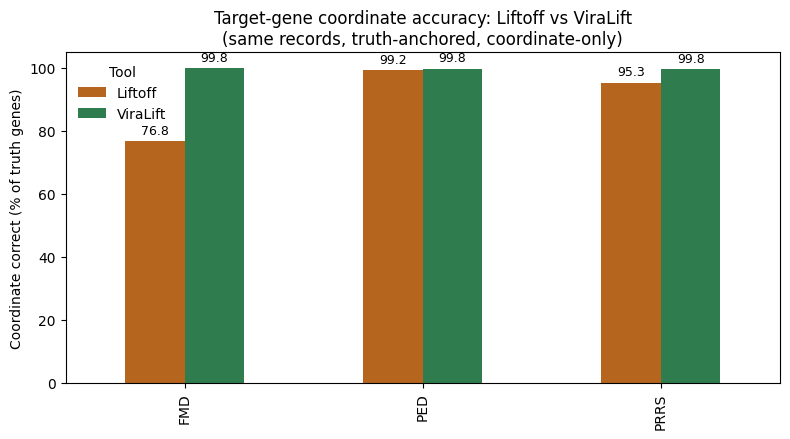

In [5]:
plot_df = summary.pivot(index='virus', columns='tool', values='coord_pct')[['Liftoff','ViraLift']]
ax = plot_df.plot(kind='bar', figsize=(8,4.5), color=[TOOL_COLORS['Liftoff'], TOOL_COLORS['ViraLift']])
ax.set_ylim(0,105); ax.set_ylabel('Coordinate correct (% of truth genes)'); ax.set_xlabel('')
ax.set_title('Target-gene coordinate accuracy: Liftoff vs ViraLift\n(same records, truth-anchored, coordinate-only)')
ax.legend(title='Tool', frameon=False)
for c in ax.containers: ax.bar_label(c, fmt='%.1f', padding=3, fontsize=9)
ax.figure.tight_layout(); ax.figure.savefig(OUTPUT_DIR / 'liftoff_accuracy.png', dpi=180, bbox_inches='tight')
wide


In [6]:
# Per-gene breakdown (where does each tool win/lose?)
per_gene = (cov_df.groupby(['virus','gene','tool'])
            .agg(n=('found','size'), correct=('found','sum')).reset_index())
per_gene['pct'] = (per_gene['correct']/per_gene['n']*100).round(1)
per_gene = per_gene.pivot_table(index=['virus','gene'], columns='tool', values='pct', fill_value=0)
per_gene.to_csv(OUTPUT_DIR / 'liftoff_per_gene.tsv', sep='\t')
per_gene


tool         Liftoff  ViraLift
virus gene                    
FMD   2A         3.1     100.0
      2B       100.0     100.0
      2C       100.0     100.0
      3A        91.8      99.0
      3B        93.8     100.0
      3Cpro    100.0     100.0
      3Dpol    100.0     100.0
      Lpro      87.8     100.0
      VP1       52.6     100.0
      VP2       55.1      99.0
      VP3       52.6     100.0
      VP4       84.7     100.0
PED   E        100.0     100.0
      M        100.0     100.0
      N        100.0     100.0
      ORF1a    100.0     100.0
      ORF1b     87.5      87.5
      ORF3      97.8     100.0
      S         99.0     100.0
PRRS  ORF1a     93.5     100.0
      ORF1b     94.3      98.9
      ORF2a     96.0     100.0
      ORF2b     91.8      98.0
      ORF3      96.0     100.0
      ORF4      96.0     100.0
      ORF5      96.0     100.0
      ORF6      96.0     100.0
      ORF7      96.0     100.0

## Buckets, disagreements and failure modes

Reported the same way as `gatu_50case_validate.ipynb` and `../02_lifting_accuracy/`, so the three
units are directly comparable: **exact / coord_only / failed** on the same lift, per-gene exact
rate, the (record, gene) pairs where the tools disagree, and a per-miss table with
`delta_start` / `delta_end` / IoU. A gene whose misses all share the same delta is a boundary
**convention** difference, not a detection failure — read it that way before writing it up.

In [7]:
# ---- exact / coord_only / failed, same buckets as 02_lifting_accuracy and gatu_50case ----
b = cov_df.assign(bucket=lambda d: d.apply(
        lambda r: 'exact' if r['exact'] else ('coord_only' if r['found'] else 'failed'), axis=1))
buckets = (b.pivot_table(index=['virus','tool'], columns='bucket', values='gene',
                         aggfunc='size', fill_value=0)
             .reindex(columns=['exact','coord_only','failed'], fill_value=0))
buckets['total'] = buckets.sum(axis=1)
buckets['accuracy_pct'] = ((buckets['exact']+buckets['coord_only'])/buckets['total']*100).round(2)
buckets.to_csv(OUTPUT_DIR / 'liftoff_buckets.tsv', sep='\t')
print(buckets.to_string())

# exact-match rate per gene — a gene at 0% exact for BOTH tools is an annotation-convention
# gene (e.g. PRRSV ORF1b, a -1 frameshift product), not a tool failure.
exact_pg = (b.groupby(['virus','gene','tool'])['exact'].mean().mul(100).round(1)
              .unstack('tool'))
exact_pg.to_csv(OUTPUT_DIR / 'liftoff_exact_per_gene.tsv', sep='\t')
exact_pg

bucket          exact  coord_only  failed  total  accuracy_pct
virus tool                                                    
FMD   Liftoff     863          37     272   1172         76.79
      ViraLift   1138          32       2   1172         99.83
PED   Liftoff     493           8       4    505         99.21
      ViraLift    500           4       1    505         99.80
PRRS  Liftoff     670          89      37    796         95.35
      ViraLift    706          88       2    796         99.75


tool         Liftoff  ViraLift
virus gene                    
FMD   2A         3.1      83.7
      2B       100.0     100.0
      2C       100.0     100.0
      3A        88.8      99.0
      3B        93.8     100.0
      3Cpro     92.9     100.0
      3Dpol    100.0     100.0
      Lpro      83.7     100.0
      VP1       44.3      83.5
      VP2       55.1      99.0
      VP3       39.2     100.0
      VP4       82.7     100.0
PED   E        100.0     100.0
      M        100.0     100.0
      N        100.0     100.0
      ORF1a    100.0     100.0
      ORF1b     37.5      50.0
      ORF3      95.7     100.0
      S         96.9      99.0
PRRS  ORF1a     91.9      98.4
      ORF1b      0.0       0.0
      ORF2a     91.0     100.0
      ORF2b     91.8      98.0
      ORF3      96.0     100.0
      ORF4      96.0     100.0
      ORF5      96.0     100.0
      ORF6      96.0     100.0
      ORF7      96.0     100.0

In [8]:
# ---- where the two tools disagree, and how each one misses ----
side = cov_df.pivot_table(index=['virus','accession','gene'], columns='tool',
                          values='found', aggfunc='first')
side.to_csv(OUTPUT_DIR / 'liftoff_side_by_side.tsv', sep='\t')
if {'Liftoff','ViraLift'} <= set(side.columns):
    dis = side[side['Liftoff'] != side['ViraLift']].reset_index()
    dis.to_csv(OUTPUT_DIR / 'liftoff_disagreements.tsv', sep='\t', index=False)
    print(f'{len(dis)} (virus, record, gene) disagreements -> liftoff_disagreements.tsv')
    print(dis.groupby(['virus','gene'])[['Liftoff','ViraLift']].sum().to_string())

# Per-miss detail: delta_start / delta_end / IoU, so a systematic boundary-convention
# offset (all deltas clustered) is distinguishable from genuine mislocation.
if not detail_df.empty:
    miss = detail_df[~detail_df['coord_correct']].copy()
    cols = ['virus','tool','record_id','pred_name','pred_start','pred_end',
            'truth_start','truth_end','delta_start','delta_end',
            'pred_minus_truth_len','iou','failure_mode']
    miss[cols].sort_values(['virus','tool','pred_name','record_id']).to_csv(
        OUTPUT_DIR / 'liftoff_failure_detail.tsv', sep='\t', index=False)
    print(f'\n{len(miss)} misses -> liftoff_failure_detail.tsv')
    print(miss.groupby(['virus','tool','pred_name'])
              .agg(n=('iou','size'), iou_med=('iou','median'),
                   dstart_med=('delta_start','median'), dend_med=('delta_end','median'))
              .query('n >= 3').to_string())

308 (virus, record, gene) disagreements -> liftoff_disagreements.tsv
tool         Liftoff  ViraLift
virus gene                    
FMD   2A           0        95
      3A           0         7
      3B           0         6
      Lpro         0        12
      VP1          0        46
      VP2          0        43
      VP3          0        46
      VP4          0        15
PED   ORF3         0         2
      S            0         1
PRRS  ORF1a        0         4
      ORF1b        0         4
      ORF2a        0         4
      ORF2b        0         3
      ORF3         0         4
      ORF4         0         4
      ORF5         0         4
      ORF6         0         4
      ORF7         0         4

17 misses -> liftoff_failure_detail.tsv
                         n  iou_med  dstart_med  dend_med
virus tool    pred_name                                  
FMD   Liftoff 3A         6   0.7588         0.0    -110.0


In [9]:
# ---- Liftoff coverage: records/genes it produced nothing for ----
# Truth-anchored means an unmapped gene counts as incorrect (methodology section 5). Reporting it
# separately keeps 'lifted the wrong span' distinct from 'did not emit anything at all'.
emitted = set(zip(detail_df['virus'], detail_df['tool'],
                  detail_df['record_id'], detail_df['pred_name'])) if not detail_df.empty else set()
cov_df['emitted'] = [ (r.virus, r.tool, r.accession, r.gene) in emitted for r in cov_df.itertuples() ]
unmapped = (cov_df.groupby(['virus','tool'])
            .agg(truth_genes=('found','size'),
                 not_emitted=('emitted', lambda s: int((~s).sum())),
                 wrong_coords=('found', lambda s: 0)).reset_index())
w = cov_df[~cov_df['found'] & cov_df['emitted']].groupby(['virus','tool']).size()
unmapped['wrong_coords'] = [int(w.get((r.virus, r.tool), 0)) for r in unmapped.itertuples()]
unmapped['not_emitted_pct'] = (unmapped['not_emitted']/unmapped['truth_genes']*100).round(2)
unmapped.to_csv(OUTPUT_DIR / 'liftoff_failure_modes.tsv', sep='\t', index=False)
print(unmapped.to_string(index=False))
print('\nrecords for which liftoff produced any output:')
print(pd.DataFrame(run_rows).to_string(index=False))

virus     tool  truth_genes  not_emitted  wrong_coords  not_emitted_pct
  FMD  Liftoff         1172          266             6             22.7
  FMD ViraLift         1172            0             2              0.0
  PED  Liftoff          505            0             4              0.0
  PED ViraLift          505            0             1              0.0
 PRRS  Liftoff          796           35             2              4.4
 PRRS ViraLift          796            0             2              0.0

records for which liftoff produced any output:
virus  query_records ref_feature_type  records_liftoff_produced_output
 PRRS            100              CDS                               96
  FMD            100      mat_peptide                               98
  PED            100              CDS                               98
